# Hate Speech Detection Project
## **CS 4120 | By Mahika Sharma, Aparajitha Karipineni, and Maithili Ubgade**

## Mahika Sharma: Data processing + Random Forest 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

# NLTK tools for Twitter-specific tokenization, stopword removal, and lemmatization
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer

# scikit-learn: feature extraction, models, and evaluation metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch for LSTM implementation
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


## 1. Load Data

Dataset: Davidson et al. (2017) : *Automated Hate Speech Detection and the Problem of Offensive Language*

**Label key:**
- `0` = hate speech  
- `1` = offensive language  
- `2` = neither

In [5]:
DATA_PATH = 'labeled_data.csv'
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loaded 24,783 rows, 7 columns


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [6]:
# Rename for clarity
df = df.rename(columns={
    'class': 'label',
    'hate_speech': 'n_hate',
    'offensive_language': 'n_offensive',
    'neither': 'n_neither',
    'count': 'n_annotators'
})
# Drop redundant CSV row-index column if present
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])

LABEL_NAMES = {0: 'hate_speech', 1: 'offensive', 2: 'neither'}
df['label_name'] = df['label'].map(LABEL_NAMES)

print(df.dtypes)
df.head()

n_annotators     int64
n_hate           int64
n_offensive      int64
n_neither        int64
label            int64
tweet           object
label_name      object
dtype: object


,n_annotators,n_hate,n_offensive,n_neither,label,tweet,label_name
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,neither
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive


## 2. Exploratory Data Analysis

             count   pct
label_name              
offensive    19190  77.4
neither       4163  16.8
hate_speech   1430   5.8


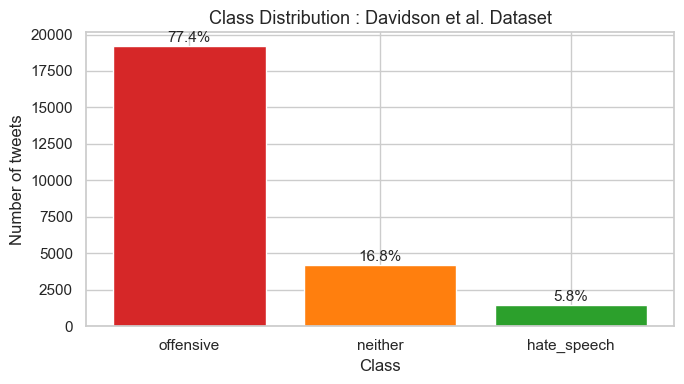

In [8]:
# Class distribution
counts = df['label_name'].value_counts()
pcts   = df['label_name'].value_counts(normalize=True) * 100

dist = pd.DataFrame({'count': counts, 'pct': pcts.round(1)})
print(dist)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dist.index, dist['count'], color=['#d62728', '#ff7f0e', '#2ca02c'])
for bar, pct in zip(bars, dist['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{pct}%', ha='center', va='bottom', fontsize=11
    )
ax.set_title('Class Distribution : Davidson et al. Dataset', fontsize=13)
ax.set_ylabel('Number of tweets')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

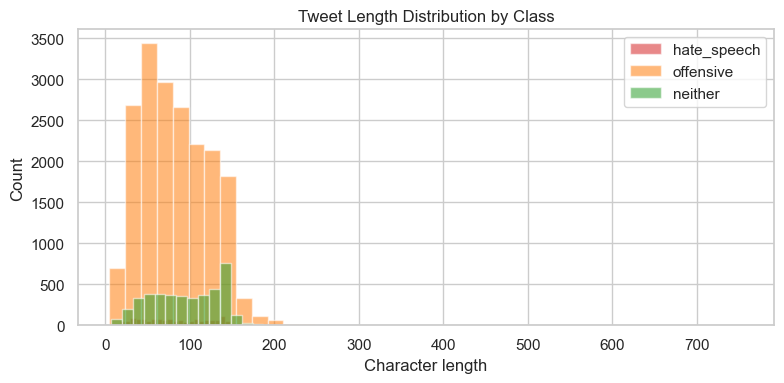

               count  mean   std  min   25%   50%    75%    max
label_name                                                     
hate_speech   1430.0  84.6  40.5  5.0  49.0  82.0  121.0  254.0
neither       4163.0  94.9  41.1  7.0  60.0  97.0  132.0  522.0
offensive    19190.0  83.5  41.5  5.0  50.0  78.0  115.0  754.0


In [9]:
# Tweet length distribution by class
df['tweet_len'] = df['tweet'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip(['hate_speech', 'offensive', 'neither'],
                         ['#d62728', '#ff7f0e', '#2ca02c']):
    ax.hist(df[df['label_name'] == label]['tweet_len'],
            bins=40, alpha=0.55, label=label, color=color)
ax.set_title('Tweet Length Distribution by Class')
ax.set_xlabel('Character length')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label_name')['tweet_len'].describe().round(1))

In [10]:
# Each tweet was labeled by at least 3 CrowdFlower workers.
# We measure agreement using majority vote share: the fraction
# of annotators who voted for the winning label.
# A score of 1.0 = unanimous; lower scores = contested tweets.

In [11]:
# Majority vote share: votes for the winning label / total annotators
votes_for_label = df.apply(
    lambda row: row[['n_hate', 'n_offensive', 'n_neither']].max(), axis=1
)
df['agreement'] = votes_for_label / df['n_annotators']

print('Agreement score summary:')
print(df['agreement'].describe().round(3))
print(f"\nUnanimous (agreement=1.0):   {(df['agreement'] == 1.0).sum():,} "
      f"({(df['agreement'] == 1.0).mean()*100:.1f}%)")
print(f"Contested (agreement<=0.5):  {(df['agreement'] <= 0.5).sum():,} "
      f"({(df['agreement'] <= 0.5).mean()*100:.1f}%)")

Agreement score summary:
count    24783.000
mean         0.905
std          0.149
min          0.444
25%          0.667
50%          1.000
75%          1.000
max          1.000
Name: agreement, dtype: float64

Unanimous (agreement=1.0):   17,482 (70.5%)
Contested (agreement<=0.5):  60 (0.2%)


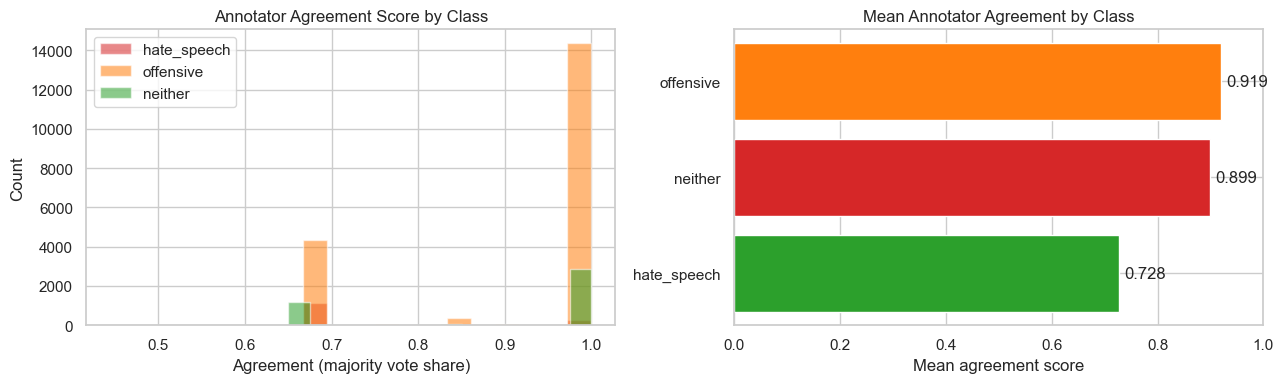

In [12]:
#  Agreement distribution by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip(['hate_speech', 'offensive', 'neither'],
                         ['#d62728', '#ff7f0e', '#2ca02c']):
    axes[0].hist(df[df['label_name'] == label]['agreement'],
                 bins=20, alpha=0.55, label=label, color=color)
axes[0].set_title('Annotator Agreement Score by Class')
axes[0].set_xlabel('Agreement (majority vote share)')
axes[0].set_ylabel('Count')
axes[0].legend()

mean_agreement = df.groupby('label_name')['agreement'].mean().sort_values()
axes[1].barh(mean_agreement.index, mean_agreement.values,
             color=['#2ca02c', '#d62728', '#ff7f0e'])
axes[1].set_title('Mean Annotator Agreement by Class')
axes[1].set_xlabel('Mean agreement score')
axes[1].set_xlim(0, 1)
for i, v in enumerate(mean_agreement.values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

In [13]:
#  Annotator count distribution
print('Number of annotators per tweet:')
print(df['n_annotators'].value_counts().sort_index())

# Most contested tweets
print('\n MOST CONTESTED TWEETS (lowest agreement) ')
pd.set_option('display.max_colwidth', 100)
print(df.nsmallest(5, 'agreement')[
    ['tweet', 'label_name', 'agreement', 'n_hate', 'n_offensive', 'n_neither']
].to_string(index=False))

Number of annotators per tweet:
n_annotators
3    22807
4      211
6     1571
7       27
9      167
Name: count, dtype: int64

 MOST CONTESTED TWEETS (lowest agreement) 
                                                                                                                                         tweet  label_name  agreement  n_hate  n_offensive  n_neither
HOT ISIS SOCIAL MEDIA PHOTO: Laughing Jihadis Get Baby To Kick Severed Head &#8211; ***warning, graphic*** http://t.co/7Zr8daxNg4 #tcot #pjnet   offensive   0.444444       2            4          3
                                                                                            NBA ALLSTAR weekend is an unofficial negro holiday   offensive   0.444444       3            4          2
      RT @DaTbOySmOkEyy: Shawty said you not gone understand america unless you went to a PWI school, crackers already brainwashed her smh lol hate_speech   0.444444       4            3          2
  "@RTNBA: Drakes new shoes that will 

In [14]:
# Sample tweets per class
for label_id, name in LABEL_NAMES.items():
    print(f'\n=== {name.upper()} (label={label_id}) ===')
    for i, tweet in enumerate(
        df[df['label'] == label_id]['tweet'].sample(3, random_state=42), 1
    ):
        print(f'  {i}. {tweet}')


=== HATE_SPEECH (label=0) ===
  1. @AustinG1135 I do not like talking to you faggot and I did but in a nicely way fag
  2. RT @mitchmancuso: @BrantPrintup:What straight guys take a picture of themselves naked in a hot tun.What fags @jakesiwy @Ryan_Murphy3 @Randy&#8230;
  3. @clinchmtn316 @sixonesixband AMERICA today, the rule of thumb is: when in doubt, blame "whitey"

=== OFFENSIVE (label=1) ===
  1. Why is it everytime I go to cracker barrel the girl with great tits that seats you who is your waitress nope its the chick with 2 teeth
  2. Run that nigga, you don't want that nigga, but I need a bad bitch that's hotter than me
  3. I need a girl from Jamaica I can't fuck with these basic black bitches

=== NEITHER (label=2) ===
  1. RT @chicagotribune: Chicago will not refund $7.7 million made from red light tickets issued after yellow lights were shortened http://t.co/&#8230;
  2. Sometimes, even I gotta tell these hoes to grow up smh
  3. &#8216;Chillin&#8217; With My Homie Or What&#

## 3. Text Preprocessing

Steps applied to each tweet:
1. Lowercase
2. Remove URLs, `RT` tags, hashtag `#` symbol (keep the word)
3. Tokenize with NLTK `TweetTokenizer` (handles Twitter-specific text well)
4. Remove stopwords
5. Keep alphabetic tokens only
6. Lemmatize

In [16]:
# TweetTokenizer is preferred over standard tokenizers for Twitter data:
# it handles @mentions, emoticons, and repeated characters natively
# strip_handles=True removes @mentions; reduce_len=True normalizes elongated words
tokenizer  = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))


def preprocess(text: str) -> str:
    """Clean and normalize a tweet for use as model input.

    Steps:
        1. Remove URLs (not informative for hate speech classification)
        2. Remove RT tags (retweet markers add noise)
        3. Strip hashtag # symbol but keep the word (preserves semantic content)
        4. Tokenize using TweetTokenizer
        5. Remove stopwords and non-alphabetic tokens
        6. Lemmatize to reduce vocabulary size

    Args:
        text: Raw tweet string.

    Returns:
        Cleaned, space-joined token string.
    """
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\brt\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'#(\w+)', r'\1', text)
    tokens = tokenizer.tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok.isalpha() and tok not in STOP_WORDS
    ]
    return ' '.join(tokens)


df['clean_tweet'] = df['tweet'].apply(preprocess)

# Sanity check: inspect before/after pairs to verify preprocessing is working as expected
pd.set_option('display.max_colwidth', 120)
df[['tweet', 'clean_tweet', 'label_name']].sample(5, random_state=0)

,tweet,clean_tweet,label_name
4129,@Misplaced_Momma \nHello dare momma. I show glad dat u follow me. U lbe screamin hot in dem pitchers. \nYou eva b wi...,hello dare momma show glad dat u follow u lbe screamin hot dem pitcher eva b wit colored men,neither
15081,RT @DymondMarie1: Shoutout to your main bitch !,shoutout main bitch,offensive
16547,RT @MsKeeKee90s: Throw it up! Like a pizza! Get stirring in that pussy like a feature &#128514;&#128514;&#128514; @t...,throw like pizza get stirring pussy like feature,offensive
4273,@Nien_Nunb what did you search? Gay redneck episode 1 play?,search gay redneck episode play,hate_speech
4254,@Ncoleycole u still a mutt tho lol,u still mutt tho lol,neither


In [17]:
# Drop rows where preprocessing produced an empty string
empty_mask = df['clean_tweet'].str.strip() == ''
print(f'Dropping {empty_mask.sum()} empty tweets after preprocessing.')
df = df[~empty_mask].reset_index(drop=True)
print(f'Remaining rows: {len(df):,}')

Dropping 9 empty tweets after preprocessing.
Remaining rows: 24,774


## 4. Train / Test Split

In [19]:
X = df['clean_tweet']
y = df['label']

# stratify=y ensures each split preserves the original class proportions
# (77.4% offensive, 16.8% neither, 5.8% hate speech)
# random_state=42 ensures reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print('\nTrain class distribution:')
print(y_train.value_counts().rename(LABEL_NAMES))
print('\nTest class distribution:')
print(y_test.value_counts().rename(LABEL_NAMES))

Train: 19,819  |  Test: 4,955

Train class distribution:
label
offensive      15349
neither         3326
hate_speech     1144
Name: count, dtype: int64

Test class distribution:
label
offensive      3838
neither         831
hate_speech     286
Name: count, dtype: int64


## 5. TF-IDF Vectorization

Fit only on the training set to avoid data leakage. Using unigrams + bigrams.

In [21]:
# TF-IDF vectorizer fit only on training data to prevent data leakage
# Applying fit_transform to train and transform (not fit_transform) to test
# ensures the test set is encoded using vocabulary learned from training only
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Train matrix: {X_train_tfidf.shape}')
print(f'Test  matrix: {X_test_tfidf.shape}')

Train matrix: (19819, 9922)
Test  matrix: (4955, 9922)


## 6. Random Forest 

`class_weight='balanced'` adjusts weights inversely proportional to class frequency ince hate speech is only ~5.8% of the data

In [23]:
# Random Forest baseline with 200 trees.
# max_depth=None: trees grow fully, allowing the model to learn complex patterns
# min_samples_split=5: prevents overfitting on very small leaf nodes
# class_weight='balanced': automatically upweights minority classes (hate speech = 5.8%)
# so the model doesn't predict 'offensive' for everything

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_tfidf, y_train)
print('Training complete.')

Training complete.


## 7. Evaluation

In [25]:
y_pred = rf.predict(X_test_tfidf)
y_pred_prob = rf.predict_proba(X_test_tfidf)

acc= accuracy_score(y_test, y_pred)
# multi_class='ovr': computes ROC-AUC using one-vs-rest strategy for multiclass
# average='macro': weights all classes equally
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=list(LABEL_NAMES.values())))

Accuracy : 0.9060
ROC-AUC  : 0.9302

              precision    recall  f1-score   support

 hate_speech       0.49      0.33      0.40       286
   offensive       0.95      0.94      0.94      3838
     neither       0.83      0.94      0.88       831

    accuracy                           0.91      4955
   macro avg       0.76      0.74      0.74      4955
weighted avg       0.90      0.91      0.90      4955



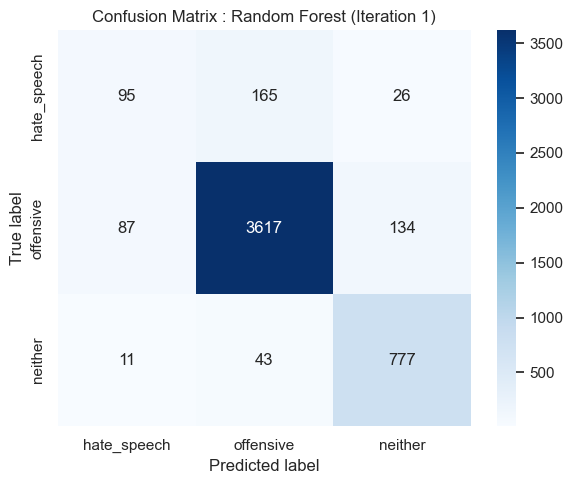

In [26]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
labels = list(LABEL_NAMES.values())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=ax
)
ax.set_title('Confusion Matrix : Random Forest (Iteration 1)', fontsize=12)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

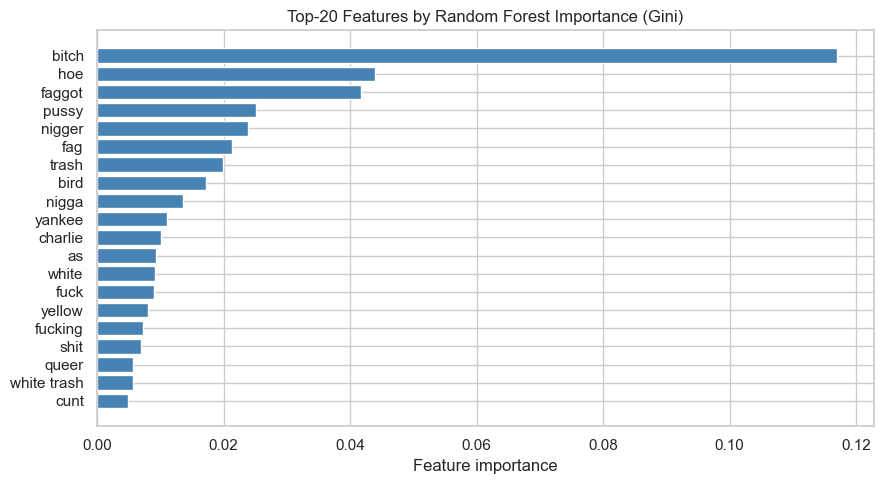

In [27]:
# Top-20 most important features (global Gini importance)
feature_names = np.array(tfidf.get_feature_names_out())
importances   = rf.feature_importances_
top_idx       = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feature_names[top_idx][::-1], importances[top_idx][::-1], color='steelblue')
ax.set_title('Top-20 Features by Random Forest Importance (Gini)', fontsize=12)
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

## 8. Logistic Regression 

In [29]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression as an interpretable linear baseline
# C=1.0: default regularization strength
# max_iter=1000: increased from default 100 to ensure convergence 
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)
print('Logistic Regression training complete.')

Logistic Regression training complete.


## 9. Evaluation

In [31]:
y_pred_lr = lr.predict(X_test_tfidf)
y_pred_prob_lr = lr.predict_proba(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_prob_lr, multi_class='ovr', average='macro')
# Macro F1 is the primary metric: it treats all classes equally regardless of support,
# making it more informative than accuracy given the class imbalance.
macro_f1 = f1_score(y_test, y_pred_lr, average='macro')

print(f'Accuracy : {acc_lr:.4f}')
print(f'ROC-AUC  : {roc_auc_lr:.4f}')
print(f"Macro F1-score: {macro_f1:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=list(LABEL_NAMES.values())))

Accuracy : 0.8607
ROC-AUC  : 0.9294
Macro F1-score: 0.7308

              precision    recall  f1-score   support

 hate_speech       0.32      0.62      0.42       286
   offensive       0.97      0.86      0.91      3838
     neither       0.79      0.94      0.86       831

    accuracy                           0.86      4955
   macro avg       0.69      0.81      0.73      4955
weighted avg       0.90      0.86      0.87      4955



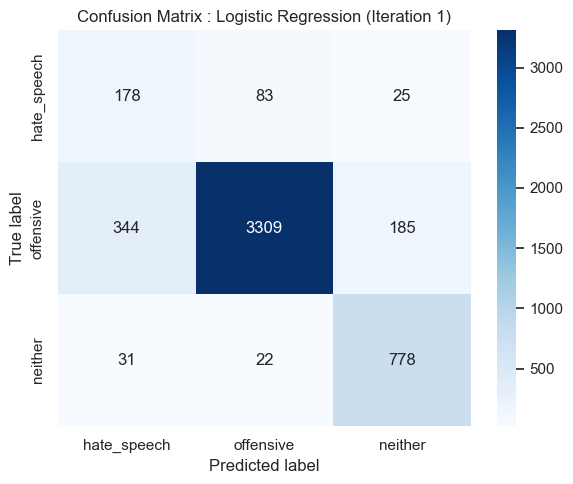

In [32]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES.values(),
    yticklabels=LABEL_NAMES.values(),
    ax=ax
)
ax.set_title('Confusion Matrix : Logistic Regression (Iteration 1)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [33]:
# use macro F1 as the comparison metric for consistency with our primary evaluation
print("\n--- Logistic Regression Hyperparameter Tuning ---")

C_values = [0.1, 1, 10]

for c in C_values:
    lr_temp = LogisticRegression(
        C=c,
        max_iter=1000,
        class_weight='balanced'
    )
    
    lr_temp.fit(X_train_tfidf, y_train)
    preds = lr_temp.predict(X_test_tfidf)
    
    f1 = f1_score(y_test, preds, average='macro')
    print(f"C={c} → Macro F1: {f1:.4f}")


--- Logistic Regression Hyperparameter Tuning ---
C=0.1 → Macro F1: 0.7205
C=1 → Macro F1: 0.7308
C=10 → Macro F1: 0.7182


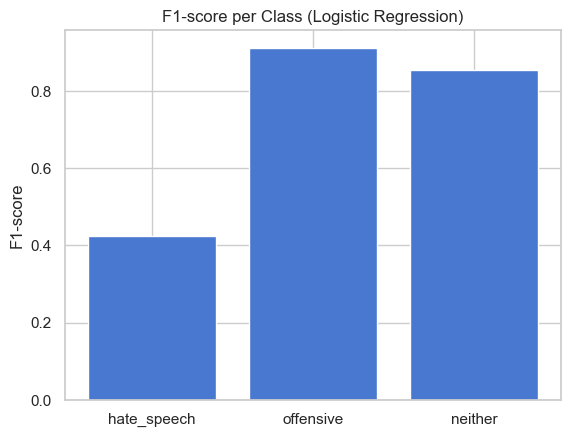

In [34]:
report = classification_report(y_test, y_pred_lr, output_dict=True)
f1_scores = [report[str(i)]['f1-score'] for i in LABEL_NAMES.keys()]
plt.bar(LABEL_NAMES.values(), f1_scores)
plt.title("F1-score per Class (Logistic Regression)")
plt.ylabel("F1-score")
plt.show()

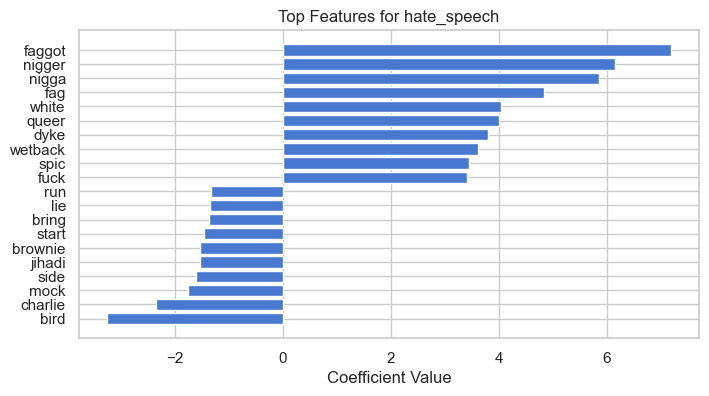

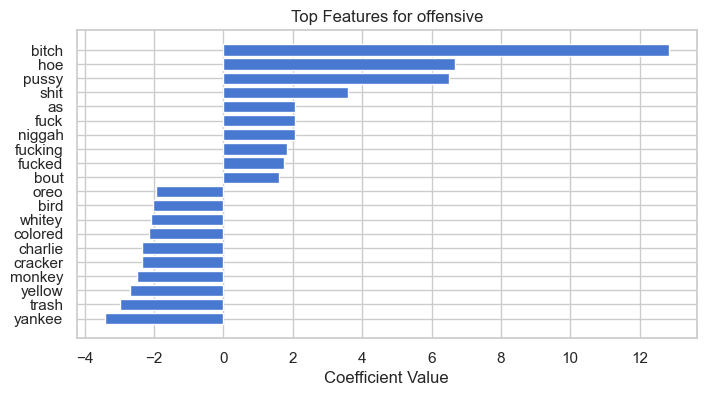

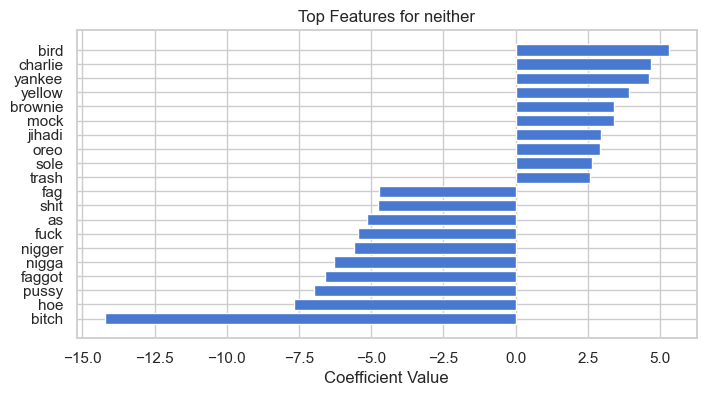

In [35]:
# Visualize the top positive and negative TF-IDF features for each class
# Positive coefficients = strong indicators FOR the class
# Negative coefficients = strong indicators AGAINST the class
top_features = 10
n_classes = len(LABEL_NAMES)

for i in range(n_classes):
    coefs = lr.coef_[i]
    top_pos_idx = np.argsort(coefs)[-top_features:]
    top_neg_idx = np.argsort(coefs)[:top_features]
    top_idx = np.concatenate([top_neg_idx, top_pos_idx])
    
    plt.figure(figsize=(8, 4))
    plt.barh(np.array(feature_names)[top_idx], coefs[top_idx])
    plt.title(f"Top Features for {list(LABEL_NAMES.values())[i]}")
    plt.xlabel("Coefficient Value")
    plt.show()

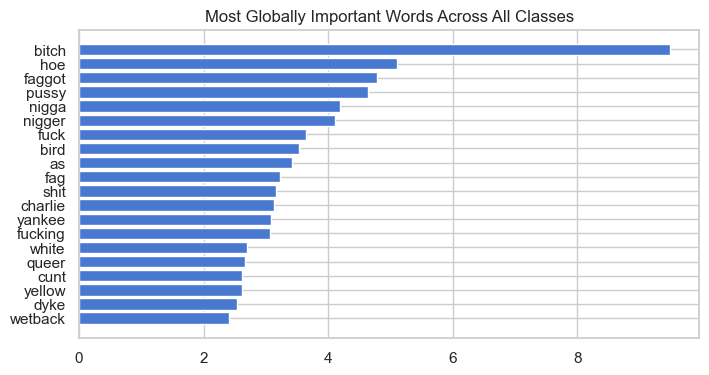

In [36]:
# Compute mean absolute coefficient across all classes to find globally influential words
# Words with high mean importance are strong predictors regardless of class,
# which can indicate vocabulary that is shared between hate speech and offensive language
importance_per_class = np.abs(lr.coef_)
mean_importance = np.mean(importance_per_class, axis=0)

top_shared_idx = np.argsort(mean_importance)[-20:]

plt.figure(figsize=(8,4))
plt.barh(np.array(feature_names)[top_shared_idx], mean_importance[top_shared_idx])
plt.title("Most Globally Important Words Across All Classes")
plt.show()

## 10. LSTM (Final Iteration)

In [38]:
def build_vocab(texts, min_freq=2):
    """Build a word-to-index vocabulary from a list of preprocessed texts.

    The LSTM requires integer token indices rather than TF-IDF vectors,
    so we build a vocabulary directly from the tokenized training data.
    This preserves token order, which TF-IDF does not.

    Special tokens:
        <PAD> (index 0): used to pad shorter sequences to MAX_LEN
        <UNK> (index 1): used for out-of-vocabulary words at inference time

    Args:
        texts: Iterable of preprocessed tweet strings.
        min_freq: Minimum token frequency to be included in vocab.
                  Filters rare/noisy tokens to reduce vocabulary size.

    Returns:
        Dictionary mapping token strings to integer indices.
    """
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(X_train)
VOCAB_SIZE = len(vocab)

vocab = build_vocab(X_train)

PAD_IDX = vocab["<PAD>"]  
UNK_IDX = vocab["<UNK>"]   

VOCAB_SIZE = len(vocab)

# Max sequence length: tweets are short, so 60 tokens captures the majority
MAX_LEN = 60

def encode(text):
    """Convert a preprocessed tweet string to a padded integer sequence.

    Sequences shorter than MAX_LEN are right-padded with PAD_IDX.
    Sequences longer than MAX_LEN are truncated.
    Unknown tokens are mapped to UNK_IDX.

    Args:
        text: Preprocessed tweet string.

    Returns:
        List of integer token indices of length MAX_LEN.
    """
    tokens = text.split()
    seq = [vocab.get(t, UNK_IDX) for t in tokens]

    if len(seq) < MAX_LEN:
        seq += [PAD_IDX] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]

    return seq

X_train_seq = np.array([encode(t) for t in X_train])
X_test_seq  = np.array([encode(t) for t in X_test])

y_train_arr = y_train.values
y_test_arr  = y_test.values

In [39]:
class TweetDataset(Dataset):
    """PyTorch Dataset wrapper for encoded tweet sequences and their labels.

    Converts numpy arrays to tensors and provides the standard
    __len__ and __getitem__ interface required by DataLoader.

    Args:
        X: 2D numpy array of shape (n_samples, MAX_LEN) containing token indices.
        y: 1D numpy array of integer class labels.
    """

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TweetDataset(X_train_seq, y_train_arr)
test_dataset  = TweetDataset(X_test_seq, y_test_arr)

# shuffle=True for training to prevent the model from learning order-dependent patterns
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

In [40]:
# Computing class weights inversely proportional to class frequency. 
# Passed to the loss function so the model penalizes misclassifying
# the rare hate speech class (5.8%) more heavily than the dominant offensive class
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_arr),
    y=y_train_arr
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

class LSTMClassifier(nn.Module):
    """Bidirectional LSTM classifier for tweet hate speech detection.

    Architecture:
        1. Embedding layer: maps token indices to dense vectors
        2. Bidirectional LSTM: processes sequence left-to-right and right-to-left,
           capturing context from both directions
        3. Mean pooling over all timesteps: aggregates sequence into a fixed vector
        4. Dropout: regularization to reduce overfitting
        5. Fully connected layer: projects to num_classes logits

    Args:
        vocab_size: Number of tokens in the vocabulary.
        embed_dim: Dimensionality of token embeddings.
        hidden_dim: Number of hidden units per LSTM direction.
                    Output size is hidden_dim * 2 due to bidirectionality.
        num_classes: Number of output classes (3: hate speech, offensive, neither).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        # padding_idx=PAD_IDX ensures padding tokens contribute zero gradient
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        # bidirectional=True doubles the effective hidden size,
        # allowing the model to use both past and future context at each token
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.5)

        # Input size is hidden_dim * 2 because of bidirectionality
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)

        out, _ = self.lstm(x)

        # Mean pooling over all timesteps instead of using only the final hidden state,
        # which helps capture information from the full sequence
        out = torch.mean(out, dim=1)

        out = self.dropout(out)

        return self.fc(out)


In [41]:
# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# final model setup: 
lstm = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=200,
    hidden_dim=256,
    num_classes=3
).to(device)

# Weighted cross-entropy loss penalizes misclassification of minority classes more heavily
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Adam optimizer with learning rate 3e-4 
optimizer = torch.optim.Adam(lstm.parameters(), lr=3e-4)

print("Using device:", device)

Using device: cpu


## Train LSTM

In [43]:
EPOCHS = 10
for epoch in range(EPOCHS):

    lstm.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # zero gradients from the previous batch to prevent accumulation
        optimizer.zero_grad()

        outputs = lstm(X_batch)

        loss = criterion(outputs, y_batch)

        # Backpropagate (compute gradients of loss with respect to all parameters)
        loss.backward()

        # Update model parameters using computed gradients
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss:.4f}")

Epoch 1/10  Loss: 252.3129
Epoch 2/10  Loss: 183.4092
Epoch 3/10  Loss: 158.5337
Epoch 4/10  Loss: 152.6627
Epoch 5/10  Loss: 138.0229
Epoch 6/10  Loss: 121.5963
Epoch 7/10  Loss: 103.6520
Epoch 8/10  Loss: 99.5269
Epoch 9/10  Loss: 92.4633
Epoch 10/10  Loss: 81.6519


## 11. Evaluation

In [45]:
# Set model to evaluation mode (disables dropout so predictions are deterministic)
lstm.eval()

y_pred_lstm = []
y_probs_lstm = []

# torch.no_grad() disables gradient computation during inference,
# reducing memory usage and speeding up evaluation
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        outputs = lstm(X_batch)

        # Convert raw logits to probabilities with softmax, then take argmax for class prediction
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_pred_lstm.extend(preds.cpu().numpy())
        y_probs_lstm.extend(probs.cpu().numpy())

acc = accuracy_score(y_test_arr, y_pred)

roc_auc = roc_auc_score(
    y_test_arr,
    y_probs_lstm,
    multi_class='ovr',
    average='macro'
)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print(classification_report(
    y_test_arr,
    y_pred_lstm,
    target_names=list(LABEL_NAMES.values())
))

Accuracy : 0.9060
ROC-AUC  : 0.9027
              precision    recall  f1-score   support

 hate_speech       0.28      0.57      0.38       286
   offensive       0.97      0.85      0.90      3838
     neither       0.78      0.93      0.85       831

    accuracy                           0.85      4955
   macro avg       0.67      0.78      0.71      4955
weighted avg       0.89      0.85      0.86      4955



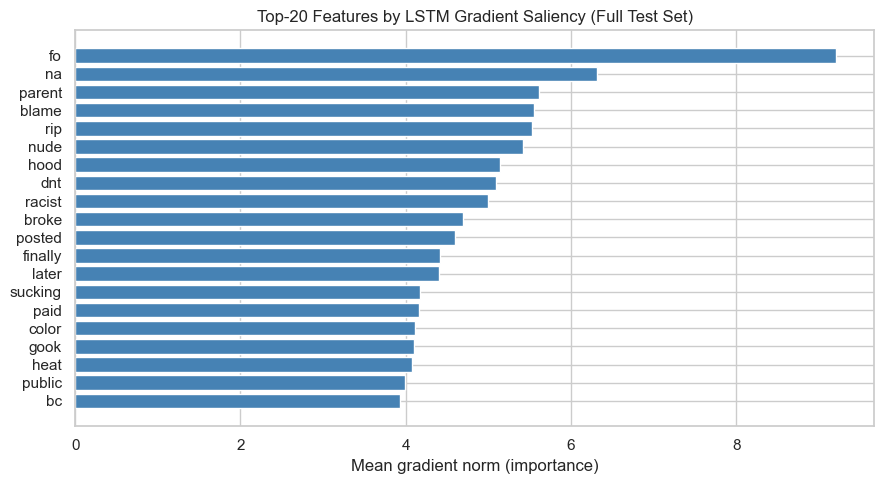

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def get_token_importance_scores(model, vocab, device, top_n=20):
    """Compute token importance scores using gradient saliency.

    For each test example, computes the gradient of the predicted class score
    with respect to the input embeddings. The L2 norm of the gradient for each
    token position is used as a proxy for how much that token influenced the
    prediction. Scores are averaged across all test examples per token.

    This provides interpretability for the LSTM analogous to feature importance
    in Random Forest or coefficient analysis in Logistic Regression.

    Args:
        model: Trained LSTMClassifier.
        vocab: Token-to-index dictionary.
        device: torch.device to run inference on.
        top_n: Number of top tokens to return.

    Returns:
        Tuple of (token_list, score_list) sorted by descending importance.
    """
    model.eval()

    idx_to_token = {v: k for k, v in vocab.items()}

    token_grad_accum = defaultdict(list)

    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        for i in range(len(X_batch)):
            seq = X_batch[i].unsqueeze(0)

            embeddings = model.embedding(seq)
            embeddings.retain_grad()

            _, (h, _) = model.lstm(embeddings)

            # Concatenate forward and backward hidden states for bidirectional LSTM
            h_forward = h[-2]
            h_backward = h[-1]
            h_combined = torch.cat((h_forward, h_backward), dim=1)

            h_combined = model.dropout(h_combined)

            out = model.fc(h_combined)

            # Backpropagate from the predicted class score to get embedding gradients
            pred_class = out.argmax(dim=1)
            model.zero_grad()
            out[0, pred_class].backward()

            grads = embeddings.grad.squeeze(0)
            token_ids = seq.squeeze(0).cpu().numpy()

            for tok_id, grad in zip(token_ids, grads):
                # Skip padding and unknown tokens
                if tok_id in (vocab["<PAD>"], vocab["<UNK>"]):
                    continue
                token = idx_to_token.get(tok_id)
                if token:
                    token_grad_accum[token].append(grad.norm().item())

    # Only include tokens seen at least 5 times for stable estimates
    token_importance = {
        tok: np.mean(scores)
        for tok, scores in token_grad_accum.items()
        if len(scores) >= 5
    }

    sorted_tokens = sorted(token_importance.items(), key=lambda x: x[1], reverse=True)[:top_n]
    tokens, scores = zip(*sorted_tokens)
    return list(tokens), list(scores)


tokens, scores = get_token_importance_scores(lstm, vocab, device, top_n=20)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tokens[::-1], scores[::-1], color='steelblue')
ax.set_title('Top-20 Features by LSTM Gradient Saliency (Full Test Set)', fontsize=12)
ax.set_xlabel('Mean gradient norm (importance)')
plt.tight_layout()
plt.show()

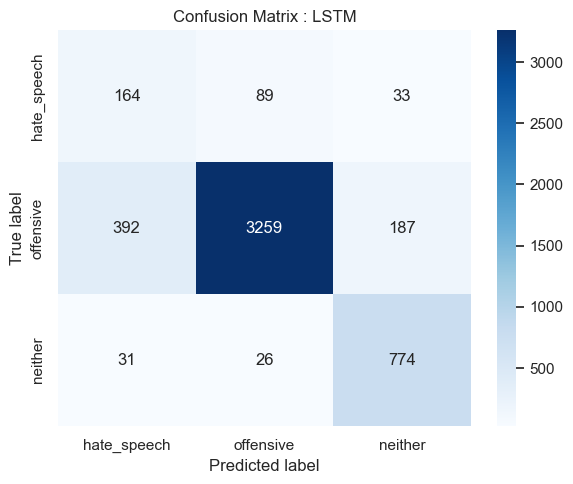

In [47]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES.values(),
    yticklabels=LABEL_NAMES.values(),
    ax=ax
)

ax.set_title('Confusion Matrix : LSTM', fontsize=12)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()